# Chapter-03. 目标检测算法基础

## 【章节目标】
- 了解计算机视觉相关任务
- 了解早期滑动窗口算法思想
- 掌握目标检测相关基本概念
- 掌握目标检测算法评估指标map

## 【章节内容】
### 3.1 计算机视觉任务

计算机视觉四大基本任务

- 图像分类
- 目标检测
- 语义分割
- 实例分割

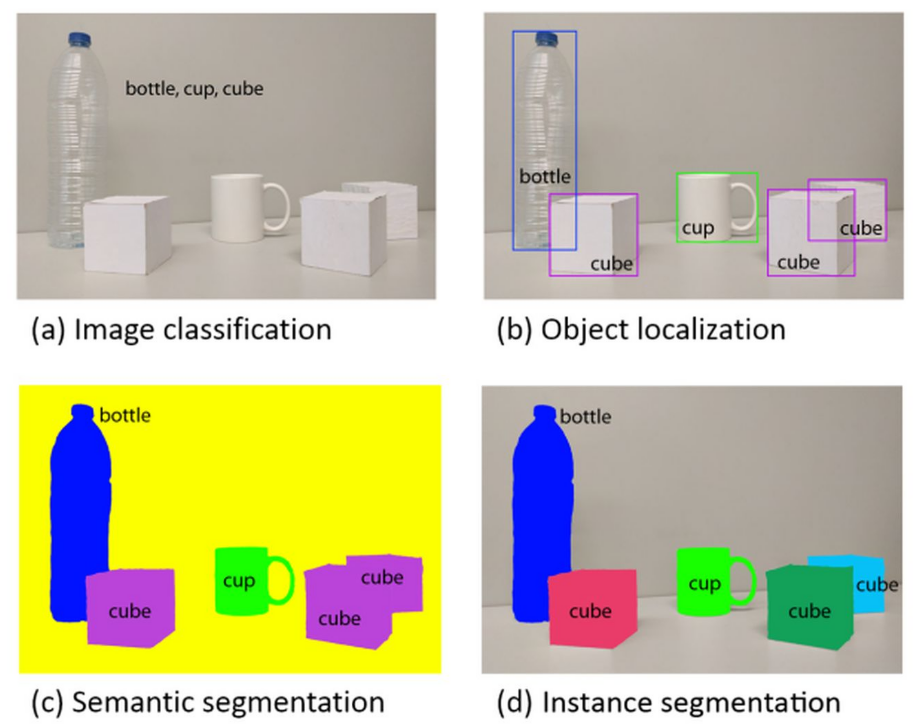

### 3.2 滑动窗口思想
#### 3.2.1 目标定位算法思想

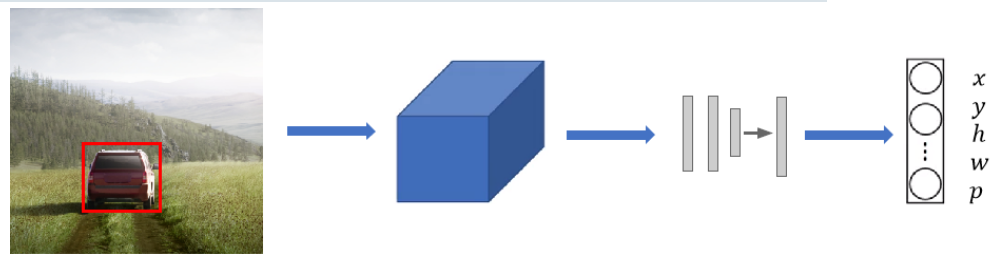

#### 3.2.2 滑动窗口算法思想

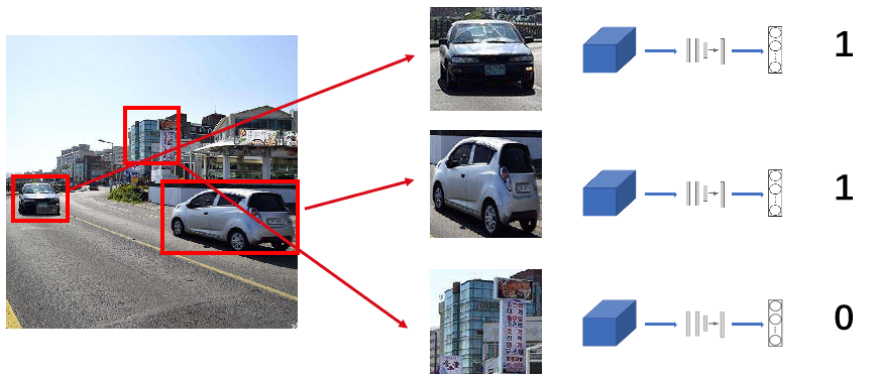

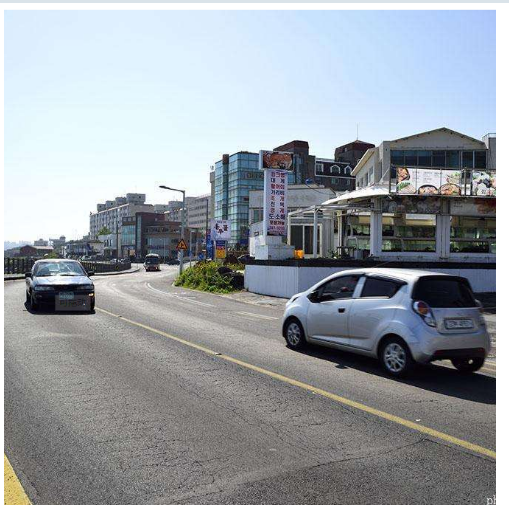

#### 3.2.3 卷积实现滑动窗口

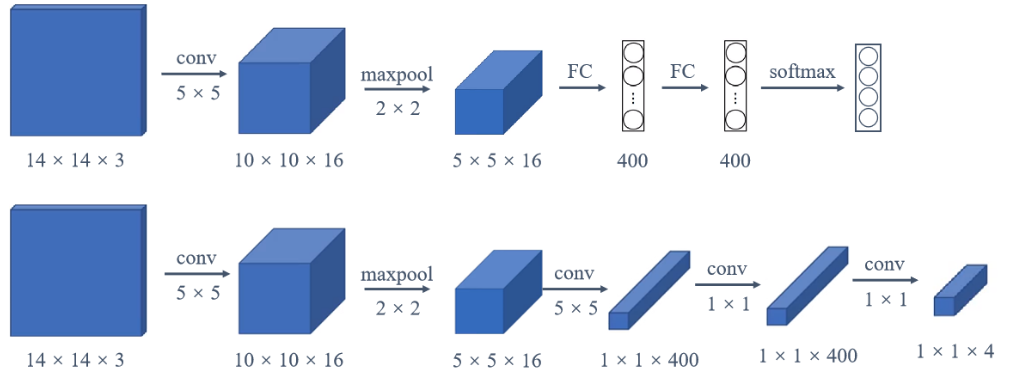

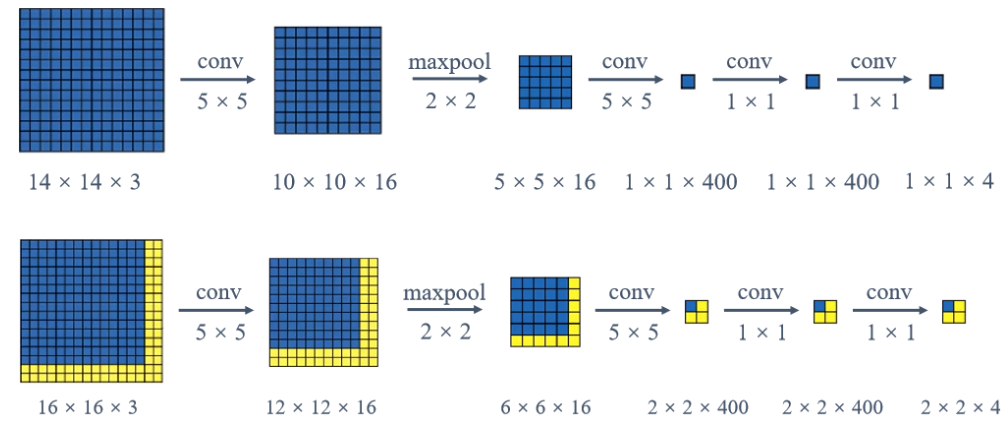

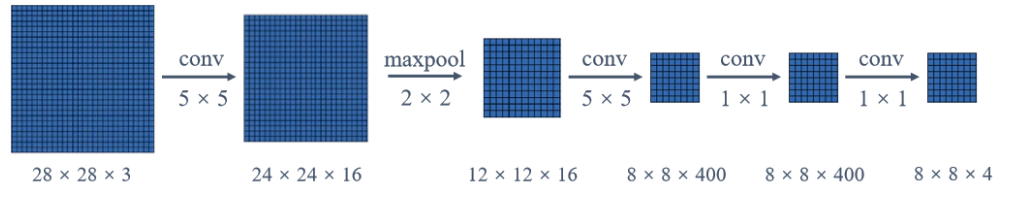

### 3.3 目标检测相关基本概念
#### 3.3.1 目标检测相关基本概念和算法
- IOU（交并比）
- Bounding Box和Anchor Box
- 编码和解码
- NMS（非极大值抑制）

#### 3.3.2 Bounding Box和Anchor Box
- Anchor Box：先验框（锚框），根据物体的大小设定的预测基准框（局部坐标系）
- bounding box：回归预测框，针对每个先验框做回归预测的到的回归框（基于该先验框的坐标系）

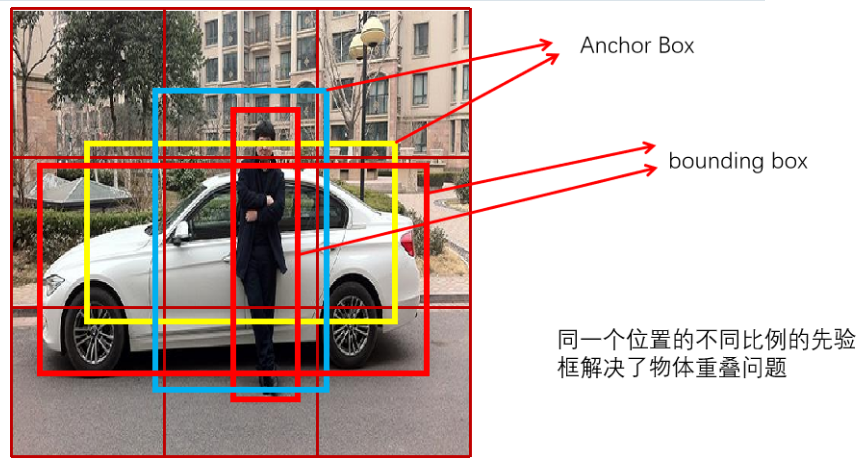

#### 3.3.3 编码和解码
- 目标检测是有监督还是无监督？目标是什么？

- 一张图片上可能有多个真实框

- 真实框位于图片的不同位置

- 真实框的标注坐标是基于整张图片的（全局坐标）

- 能否直接将真实框的全局坐标作为训练目标？

- 应该怎么做？

- 模型预测框bounding box的坐标是全局还是局部的？

- 模型预测框bounding box之间能否直接进行iou计算？

- 怎么办？

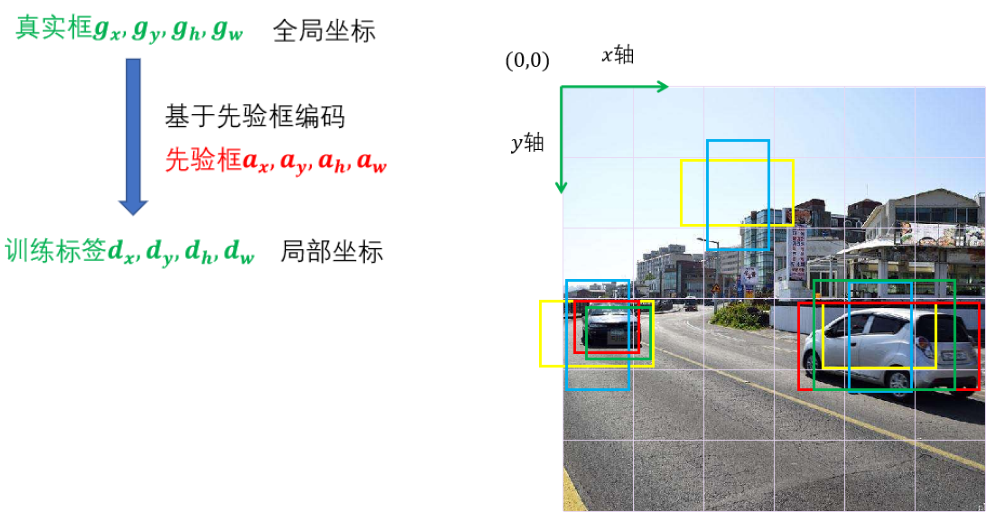

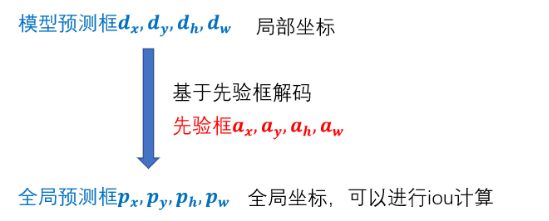

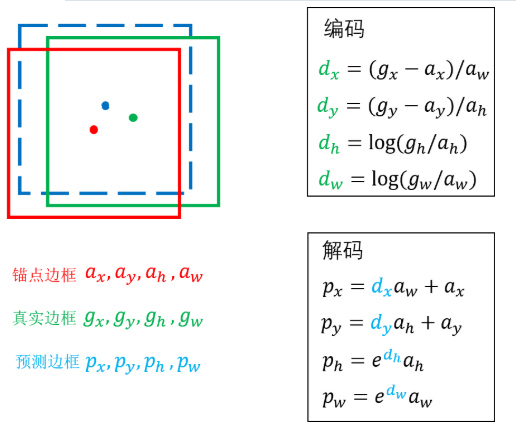

#### 3.3.4 IOU（交并比）
对于bounding box（回归框）的定位精度，有一个很重要的概念：

- 因为算法不可能百分百跟人工标注的数据完全匹配，因此就存在一个定位精度评价指标：IOU
- IOU定义了两个bounding box的重叠度

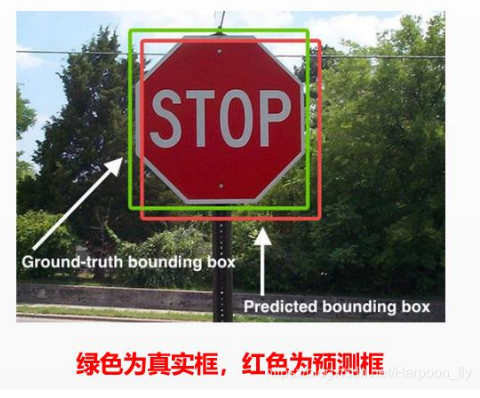

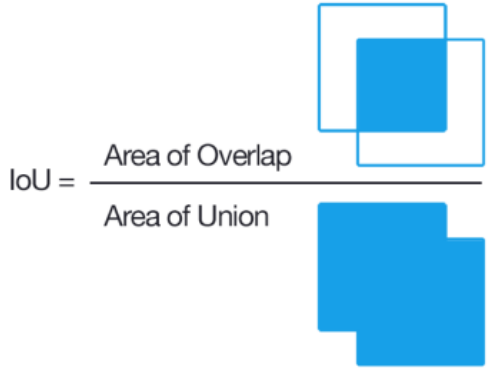

#### 3.3.5 NMS（非极大值抑制）
**NMS（非极大值抑制）介绍**

在执行目标检测任务时，算法可能对同一目标有多次检测。NMS 是一种让你确保算法只对每个对象得到一个检测的方法，即“清理检测”。如下图所示：

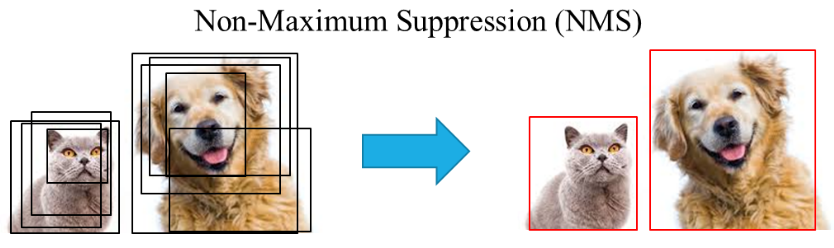

**NMS（非极大值抑制）过程**

现实中，在正式使用NMS之前，通常会有一个候选框预清理的工作（简单引入一个置信度阈值），如下图所示：

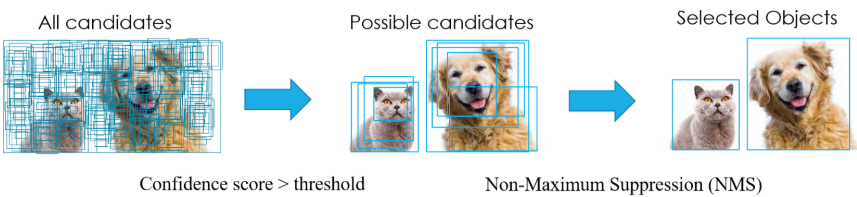

**NMS（非极大值抑制）实现步骤**

- 第一步：对 BBox 按置信度排序，选取置信度最高的 BBox（所以一开始置信度最高的 BBox 一定会被留下来）；
- 第二步：对剩下的 BBox 和已经选取的 BBox 计算 IOU，淘汰（抑制） IOU 大于设定阈值的 BBox（在图例中这些淘汰的 BBox 的置信度被设定为0）。
- 第三步：重复上述两个步骤，直到所有的 BBox 都被处理完，这时候每一轮选取的 BBox 就是最后结果。

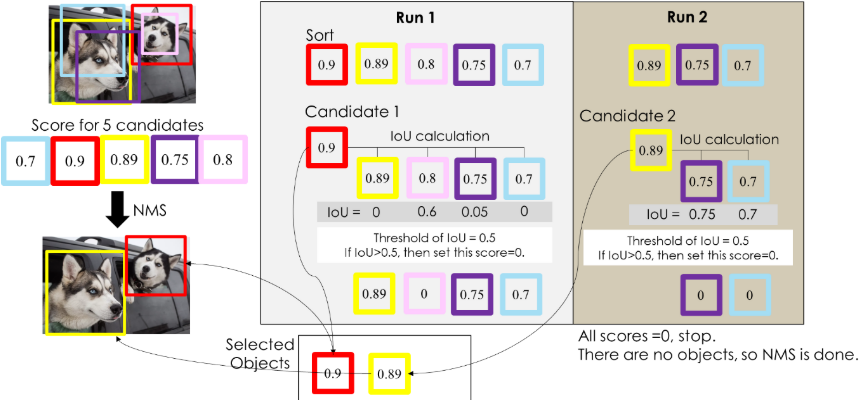

**NMS（非极大值抑制）阈值的影响**

在前面这个例子中，NMS 只运行了两轮就选取出最终结果：第一轮选择了红色 BBox，淘汰了粉色 BBox；第二轮选择了黄色 BBox，淘汰了紫色 BBox 和青色 BBox。注意到这里设定的 IOU 阈值是0.5，假设将阈值提高为0.7，结果又是如何？

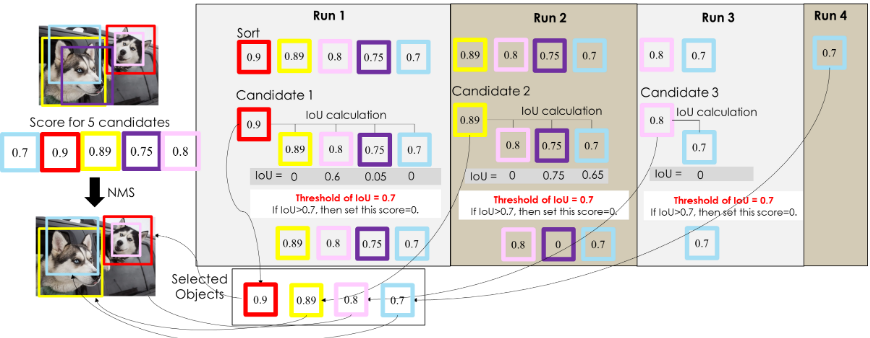

> 可以看到，NMS 用了更多轮次来确定最终结果，并且最终结果保留了更多的 BBox，但结果并不是我们想要的。因此，在使用 NMS 时，IOU 阈值的确定是比较重要的

### 3.4 目标检测模型的性能评估
#### 3.4.1 MAP（Mean Average Precision）

如何衡量目标检测算法的优劣?

- 目标检测(object detection)问题相对于一般AI分类问题更加复杂，不仅检测出目标，输出目标的类别，还要定位出目标的位置。分类问题中的简单accuray指标已经不能反映出目标检测问题结果的准确度，而mAP (Mean Average Precision）就是被用来衡量目标检测算法优劣的常用指标。
- 要理解什么是mAP，需要先弄清什么是Precision（查准率）和Recall（查全率）。

#### 3.4.2 混淆矩阵
对于二分类问题，可将样例根据其真实类别与预测类别的组合划分为：

- TP、TN、FP、FN
- TP (True Positive): 真正例。Positive指预测输出为正例，True代表预测正确。
- TN (True Negative): 真反例。预测输出为负例，而且预测正确。
- FP (False Positive): 假正例。预测输出为正例，但是预测错误。
- FN (False Negative): 假反例。预测输出为负例，但是预测错误。

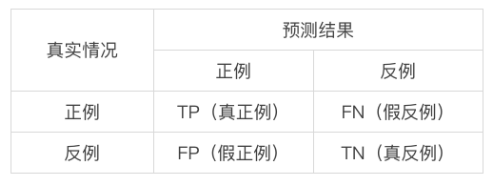

**如何计算混淆矩阵**

目标检测问题中，算法通常输出一个预测框(bounding box)来标识检出目标的位置，要衡量这个预测框与目标的实际位置(ground truth)的准确度，可以使用IoU指标。

- 我们可以设置一个阈值（threshold），通常是0.5，预测结果可以分为：
- 如果IoU >= 0.5
    - 如果预测类别也正确，认为是一个好的预测，分类为TP
    - 如果预测类别错误，认为是一个坏的预测，分类为FP
- 如果IoU < 0.5, 认为是一个坏的预测，分类为FP
- 如果一个目标出现在图像中，但是算法未检出，分类为FN
- TN（图像上所有不包含实际框和检测框的部分）通常计算中用不到。

蓝色的框是 真实框。绿色和红色的框是 预测框，绿色的框是正样本，红色的框是负样本。 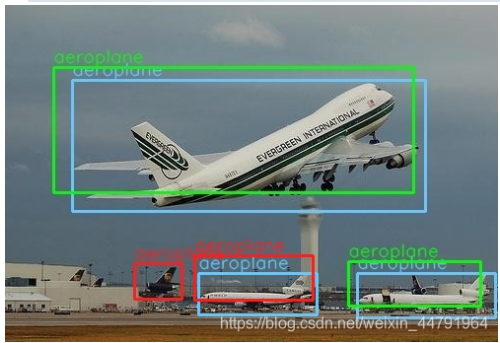

**Precision**  
Precision(查准率）: 所有预测为正例的结果中，预测正确的比率。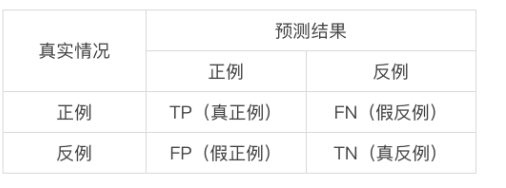

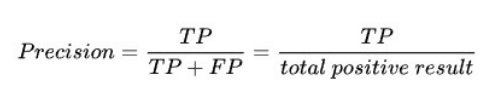

**Recall**  
Recall (查全率）：所有正例中被正确预测的比率。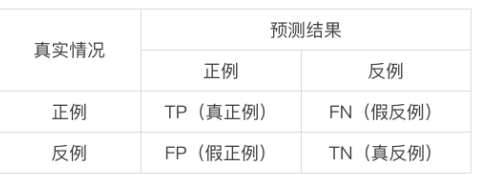  
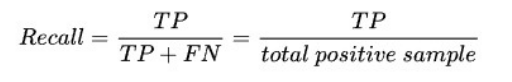

#### 3.4.3 P-R曲线
- 查全率和查准率通常是一对矛盾的度量，一般来说，查准率高时，查全率往往偏低；而查全率高时，查准率往往偏低。
- 我们如果把所有预测结果对样例进行排序，排在前面的是“最可能”的正例样本，以查准率为纵轴、查全率为横轴作图，得到一条”P-R曲线”。

P-R曲线直观的显示出一个算法在样本总体上的查全率、查准率情况。如果一个算法的P-R曲线被另一个算法的曲线完全包住，则可断言后者优于前者。但是实际中，经常不同算法的P-R曲线是互相交叉的，这时就很难直观判断出两者的优劣。这时通常会考察平衡点(BEP)、F1度量、AP等指标。

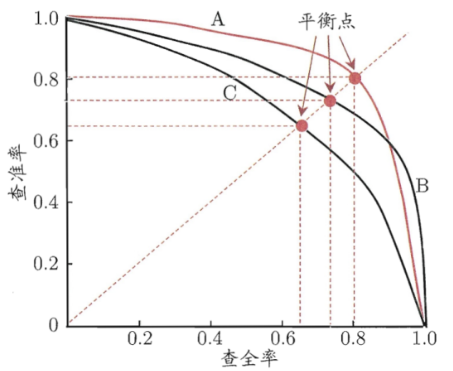

**AP**

AP（average precision 平均精度）：AP是计算单类别的模型平均准确度。对于目标检测任务，每一个类都可以计算出其Precision和Recall，每个类都可以得到一条P-R曲线，曲线下的面积就是AP的值。如果一个算法的AP值较大，也就是P-R曲线下的面积比较大，可以认为此算法查准率和查全率整体上相对较好

**mAP**  
mAP(mean of Average Precision) : 对所有类别的AP值求平均值。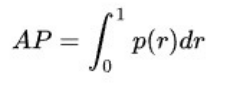